## HW 1: Sinusoids, Functions, Additive Synthesis (15 points)
For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

### Question 1 - Sinusoids (3 points)
Define the function, **genSine(f, ...)** that construct a sinusoid at frequency `f`.
The arguments should include:  
* amplitude, with default value of 1 (float)
* sample rate, with default value of 44.1kHz (float)
* time in seconds, with default value of 1 (float)
* phase offset, with default value of 0 (float)
    
and will return the numpy array containing the sinusoidal waveform.

Your function must check for appropriate input and handle any errors.
    

In [2]:
import numpy as np

def genSine(f, amp=1, fs=44100, dur=1, phi=0):
    try: 
        if amp <= 0:
            print('Amplitude must be greater than 0.')
            return None
        if dur <= 0:
            print('Time in seconds must be greater than 0.')
            return None
        if fs <= 0:
            print('Sampling rate must be greater than 0.')
            return None
        if f <= 0:
            print('Frequency must be greater than 0.')
            return None
        else: 
            amp = float(amp) # amplitude
            f = float(abs(f)) # frequency
            phi = float(phi) # phase offset
            fs = float(fs) # sampling rate
            dur = float(dur) # time/duration in seconds
            t = np.arange(0,dur,1/fs) # set up time indices
            x = amp * np.sin(2*np.pi*f*t + phi) # constructs sinusoid
            return(x)

    except TypeError:
        print('Arguments must be of type int or float.')
        return None

# uncomment test run below
#print(genSine(400))


### Question 2 - Classical Waveform (5 points)
Define a function, **genWave(freq, t, numHarms=None, A=1, phi=0, fs=44100)**, that will create one of the fundamental waveforms (saw, triangle, or square) built from the combination of sinusoids at integer multiples of a fundamental frequency.  The arguments passed will be as follows:

* freq will be the frequency in Hz (int or float).
* t will be the length of time in seconds (int or float).
* numHarms will be the number of harmonics used. If no value is given (NoneType), you should create the maximum harmonics possible given the sampling rate

The function should return a numpy array. **You may not use existing waveform functions such as those in the `scipy` library.**

Your function must check for appropriate input and handle any errors.

Try to make your function as efficient as you can, but we will not take points off for a long run time. Be mindful by using NumPy functions rather than direct iteration.

*Hint: your function should use your genSine function

**Bonus: Expand this function to create any of the classical waveforms with a new argument "type" specifying which to build.

In [3]:
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal
import math

def genWave(freq, t, numHarms=None, A=1, phi=0, fs=44100): 
    try:
        if A <= 0:
            print('Amplitude must be greater than 0.')
            return None
        if freq <= 0:
            print('Frequency must be greater than 0.')
            return None
        if fs <= 0:
            print('Sampling rate must be greater than 0.')
            return None
        if type(fs) is float:
            print("Sampling rate must be an integer.")
            return None
        else:
            freq = float(freq) # frequency in Hz
            nyquist = float(fs/2)
            if freq >= nyquist:
                print("Frequency above Nyquist, will cause aliasing.")
            t = float(t) # length of time in seconds
            A = float(A) # amplitude
            phi = float(phi) # phase offset
            fs = int(fs) # sampling rate
            if numHarms == None: # if number of harmonics is 0, create max harmonics possible by computing the Nyquist frequency
                numHarms = math.floor((fs/2)) # round down to not cause issues in range object below
            else:
                numHarms = int(numHarms) # number of harmonics

            mults = np.arange(1, numHarms+1) # multiplier for sin wave
            freqs = list(mults * freq)
            amps = list(A/mults)

            saw =  np.zeros(fs)# first initialize array that we will add to, make length
            for i in range(1, numHarms+1): 
                f = freq * i
                a = A / i
                s = genSine(f, a)
                saw += s # saw = s + saw
            return(saw)
    except TypeError:
        print('Arguments must be of type int or float.')
        return None
    
# uncomment test run below
#print(genWave(40, 2))

### Question 3 - Arpeggio (4 points)

Define the function arpegiateFreq(freq, dur), that will create a major scale arpeggio of a given frequency for a given length using your genWave() function. The arguments passed will be as follows:
* freq will be the starting/fundamental frequency in Hz (int or float)
* dur will be the length of time in seconds (int or float)

Reminder: a major scale arpeggio is built from the root, major third, and perfect 5th. You should divide the duration evenly amongst the three notes. 

The function should return a numpy array.

*Hint: your function will use the function(s) you just wrote*

Your function must check for appropriate input and handle any errors

**Bonus: Create a new function called arpegiateNote(scale, dur). Instead of the second input being frequency in Hz, the function should receive a note name like 'C'. You will need to convert this note to frequency. If you want to go the extra mile, make it case sensitive, such that an uppercase 'C' yields a C major arpeggio and lowercase 'c' yields a c minor arpeggio.

In [4]:
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal
import math

def arpegiateFreq(freq, dur):
    try:
        if freq <= 0:
            print('Frequency must be greater than 0.')
            return None
        if dur <= 0:
            print('Time in seconds must be greater than 0.')
            return None
        else:
            freq = float(freq) # frequency
            dur = float(dur) # time in sec
            interval = dur/3
            r = genWave(freq, interval)
            m3 = genWave(freq*(5/4), interval)
            p5 = genWave(freq*(3/2), interval)
            arp = np.concatenate((r, m3, p5))
            return(arp)
    except:
        print('Arguments must be of type int or float.')
        return None

# uncomment test run below
#Audio(arpegiateFreq(300, 4), rate=44100)

In [80]:
# BONUS
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal
import math

def arpegiateNote(scale, dur):
    try:
        if dur <= 0:
            print('Time in seconds must be greater than 0.')
            return None
        else:
            if scale == "C":
                freq = float(261.6)
            if scale == "Csharp" or scale == "Dflat":
                freq = float(277.2)
            if scale == "D":
                freq = float(293.7)
            if scale == "Dsharp" or scale == "Eflat":
                freq = float(311.1)
            if scale == "E":
                freq = float(329.6)
            if scale == "F":
                freq = float(349.2)
            if scale == "Fsharp" or scale == "Gflat":
                freq = float(370.0)
            if scale == "G":
                freq = float(392.0)
            if scale == "Gsharp" or scale == "Aflat":
                freq = float(415.3)
            if scale == "A":
                freq = float(440.0)
            if scale == "Asharp" or scale == "Bflat":
                freq = float(466.2)
            if scale == "B":
                freq = float(493.9)
            else:
                print('First argument must be between C, Csharp, Dflat, D, Dsharp, Eflat, E, F, Fsharp, Gflat, G, Gsharp, Ab, A, Asharp, Bflat, B as a string.')
                return None

            freq = float(freq) # frequency
            dur = float(dur) # time in sec
            interval = dur/3
            r = genWave(freq, interval)
            m3 = genWave(freq*(5/4), interval)
            p5 = genWave(freq*(3/2), interval)
            arp = np.concatenate((r, m3, p5))
            return(arp)

    except TypeError:
        print("First argument must be between C, Csharp, Dflat, D, Dsharp, Eflat, E, F, Fsharp, Gflat, G, Gsharp, Ab, A, Asharp, Bflat, B. The second argument must be an int or float.")
        return None
    


## Error handling tips and edge cases
What should happen if the frequency inputs to our functions would generate frequncies above Nyquist?

What should happen if our time inputs are negative? Or are 0?

What should happen if our frequencies are negative? Or are 0?

You should account for actual coding errors and errors that conceptually do not make sense.

### Section 4 - Using functions and graphing (3 points)
Create a 2 second F major arpeggio in an array named 'myArp'. Play back your audio.

In [9]:
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal

myArp = arpegiateFreq(349.23, 2)
Audio(myArp, rate=44100)

Remove every 4th sample of 'myArp', save as a new array, 'skipped, and play back your audio. What happened to the audio?

In [10]:
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal

fs = 44100
skipped = []
myArp = arpegiateFreq(349.23, 2)
count = 1
for n in range(len(myArp)):
    if count % 4 != 0:
        skipped.append(myArp[n])
        count += 1
    else:
        count += 1
skipped = np.array(skipped)

Audio(skipped, rate=fs)



Create a 2 Bb major arpeggio in an array named 'myArp2'. Play back your audio

In [11]:
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal

myArp2 = arpegiateFreq(466.2, 2)
Audio(myArp2, rate=44100)

Reverse 'myArp2' and save as a new array, 'reverse'. Play back your audio

In [23]:
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal

reverse = np.flip(myArp2)
Audio(reverse, rate=44100)


Graph your 4 arrays on top of one another. Make sure to label the axis and plot against time. 

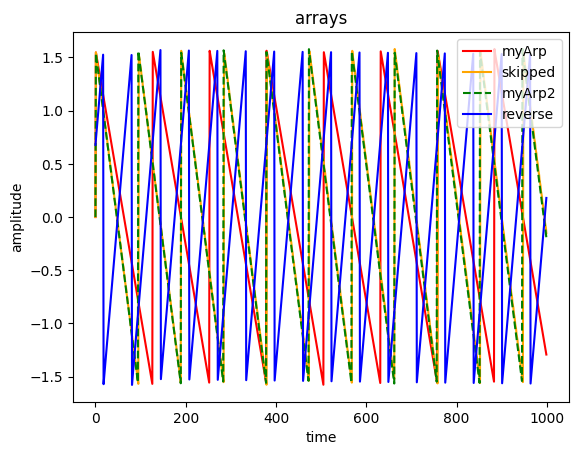

In [25]:
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal

plt.figure()
plt.plot(myArp[:1000], label="myArp", color="red")
plt.plot(skipped[:1000], label="skipped", color="orange")
plt.plot(myArp2[:1000], label="myArp2", color="green", linestyle="--")
plt.plot(reverse[:1000], label="reverse", color="blue")

plt.title("arrays")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.legend()
plt.show()
#x = np.arange(0, 2*np.pi, 0.01)    
#lt.plot(x, np.sin(x), x, np.cos(x))

Create another graph, but this time only plot the first "note" of each array

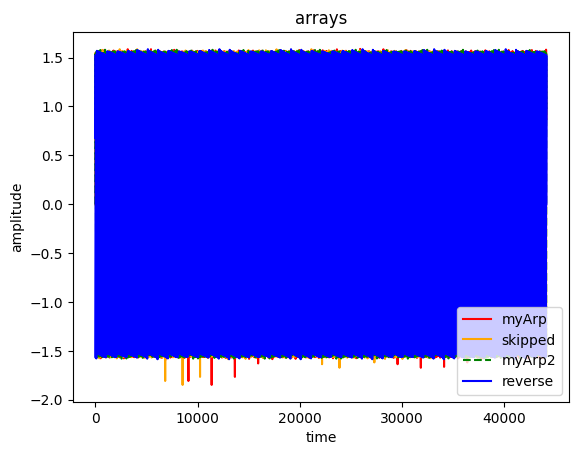

In [ ]:
import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal

plt.figure()
plt.plot(myArp[:round(len(myArp)/3)], label="myArp", color="red")
plt.plot(skipped[:round(len(skipped)/3)], label="skipped", color="orange")
plt.plot(myArp2[:round(len(myArp2)/3)], label="myArp2", color="green", linestyle="--")
plt.plot(reverse[:round(len(reverse)/3)], label="reverse", color="blue")


plt.title("arrays")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.legend()
plt.show()


### GenAI Usage Statement (if applicable)